# WESAD Dataset Exploration and Visualization

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

# Define the base path to the WESAD dataset
WESAD_BASE_PATH = '../../Dataset/WESAD/' # Adjust this path as needed

# Subjects available (S1 and S12 were discarded due to sensor malfunction)
subjects = [f'S{i}' for i in range(2, 12)] + [f'S{i}' for i in range(13, 18)]

print(f"Found {len(subjects)} subjects: {subjects}")

Found 15 subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


## Load and Inspect Data for a Single Subject

In [2]:
# Let's pick one subject to inspect in detail, e.g., S2
sample_subject = subjects[0]
subject_path = os.path.join(WESAD_BASE_PATH, sample_subject, f'{sample_subject}.pkl')

data = None
try:
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    print(f"Successfully loaded data for {sample_subject}")
except FileNotFoundError:
    print(f"Error: {subject_path} not found. Please check the WESAD_BASE_PATH and subject folders.")
except Exception as e:
    print(f"An error occurred while loading {subject_path}: {e}")

if data:
    print("\nData keys:", data.keys())
    print("Subject ID:", data['subject'])
    
    # Inspect signal data
    signal_keys = data['signal'].keys()
    print("\nSignal keys:", signal_keys)
    
    for key in signal_keys:
        print(f"Signal '{key}' data keys:", data['signal'][key].keys())
        for sensor_key, sensor_data in data['signal'][key].items():
            if isinstance(sensor_data, np.ndarray):
                print(f"  - {key} {sensor_key} shape: {sensor_data.shape}, dtype: {sensor_data.dtype}")
            else:
                print(f"  - {key} {sensor_key} type: {type(sensor_data)}")
    
    # Inspect labels
    if 'label' in data:
        print(f"\nLabel shape: {data['label'].shape}, dtype: {data['label'].dtype}")
        unique_labels, label_counts = np.unique(data['label'], return_counts=True)
        print(f"Unique labels: {unique_labels}")
        print(f"Label counts: {label_counts}")
        
        # Map labels to meaningful names (from readme)
        label_map = {
            0: 'not defined/transient',
            1: 'baseline',
            2: 'stress',
            3: 'amusement',
            4: 'meditation',
            5: 'ignored',
            6: 'ignored',
            7: 'ignored'
        }
        mapped_labels = [label_map.get(lbl, 'unknown') for lbl in unique_labels]
        print("Mapped labels:", dict(zip(unique_labels, mapped_labels)))
    else:
        print("\n'label' key not found in data.")

Successfully loaded data for S2

Data keys: dict_keys(['signal', 'label', 'subject'])
Subject ID: S2

Signal keys: dict_keys(['chest', 'wrist'])
Signal 'chest' data keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
  - chest ACC shape: (4255300, 3), dtype: float64
  - chest ECG shape: (4255300, 1), dtype: float64
  - chest EMG shape: (4255300, 1), dtype: float64
  - chest EDA shape: (4255300, 1), dtype: float64
  - chest Temp shape: (4255300, 1), dtype: float32
  - chest Resp shape: (4255300, 1), dtype: float64
Signal 'wrist' data keys: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])
  - wrist ACC shape: (194528, 3), dtype: float64
  - wrist BVP shape: (389056, 1), dtype: float64
  - wrist EDA shape: (24316, 1), dtype: float64
  - wrist TEMP shape: (24316, 1), dtype: float64

Label shape: (4255300,), dtype: int32
Unique labels: [0 1 2 3 4 6 7]
Label counts: [2142701  800800  430500  253400  537599   45500   44800]
Mapped labels: {np.int32(0): 'not defined/transient', np.int32(1): 

## Visualize Raw Sensor Data (Sample Subject)

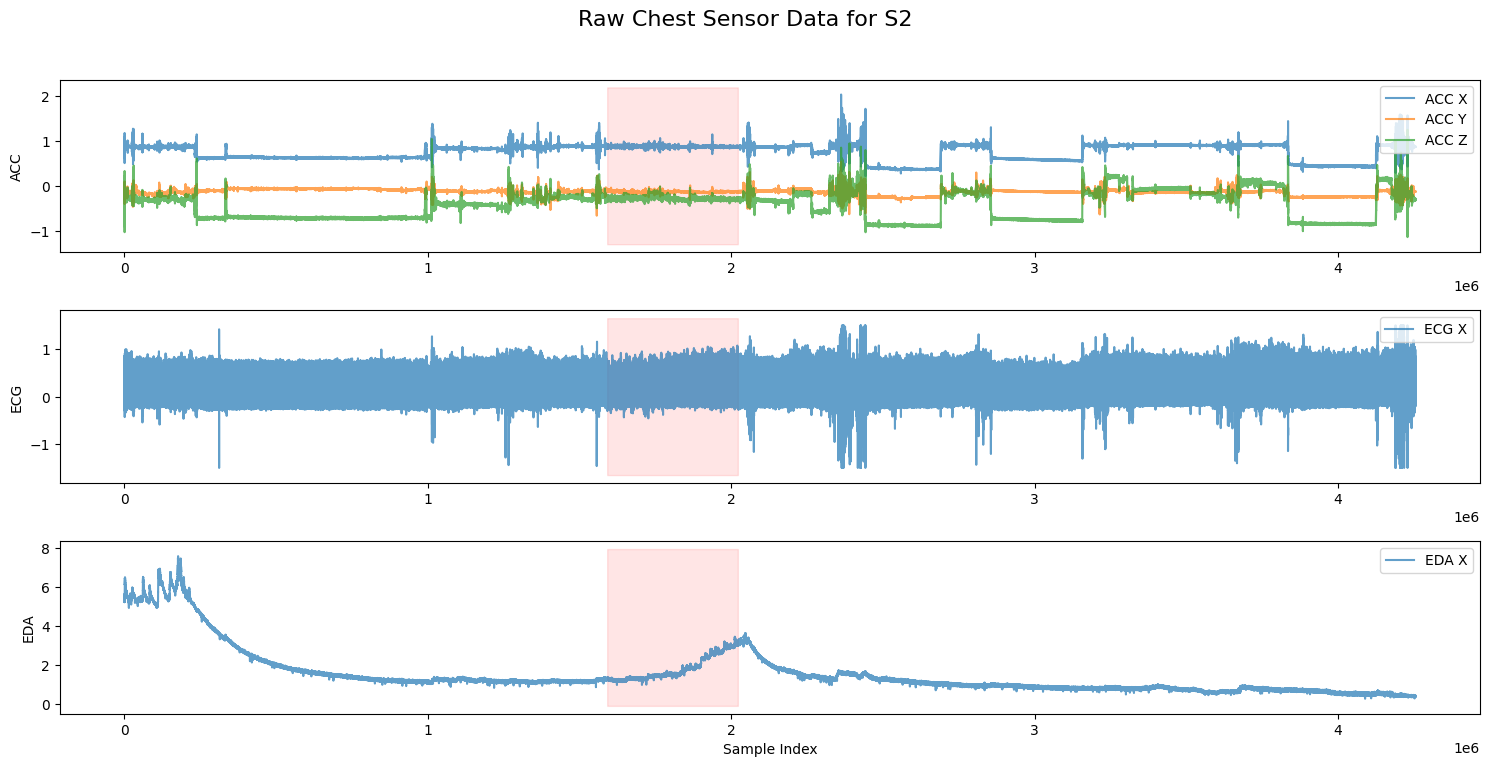

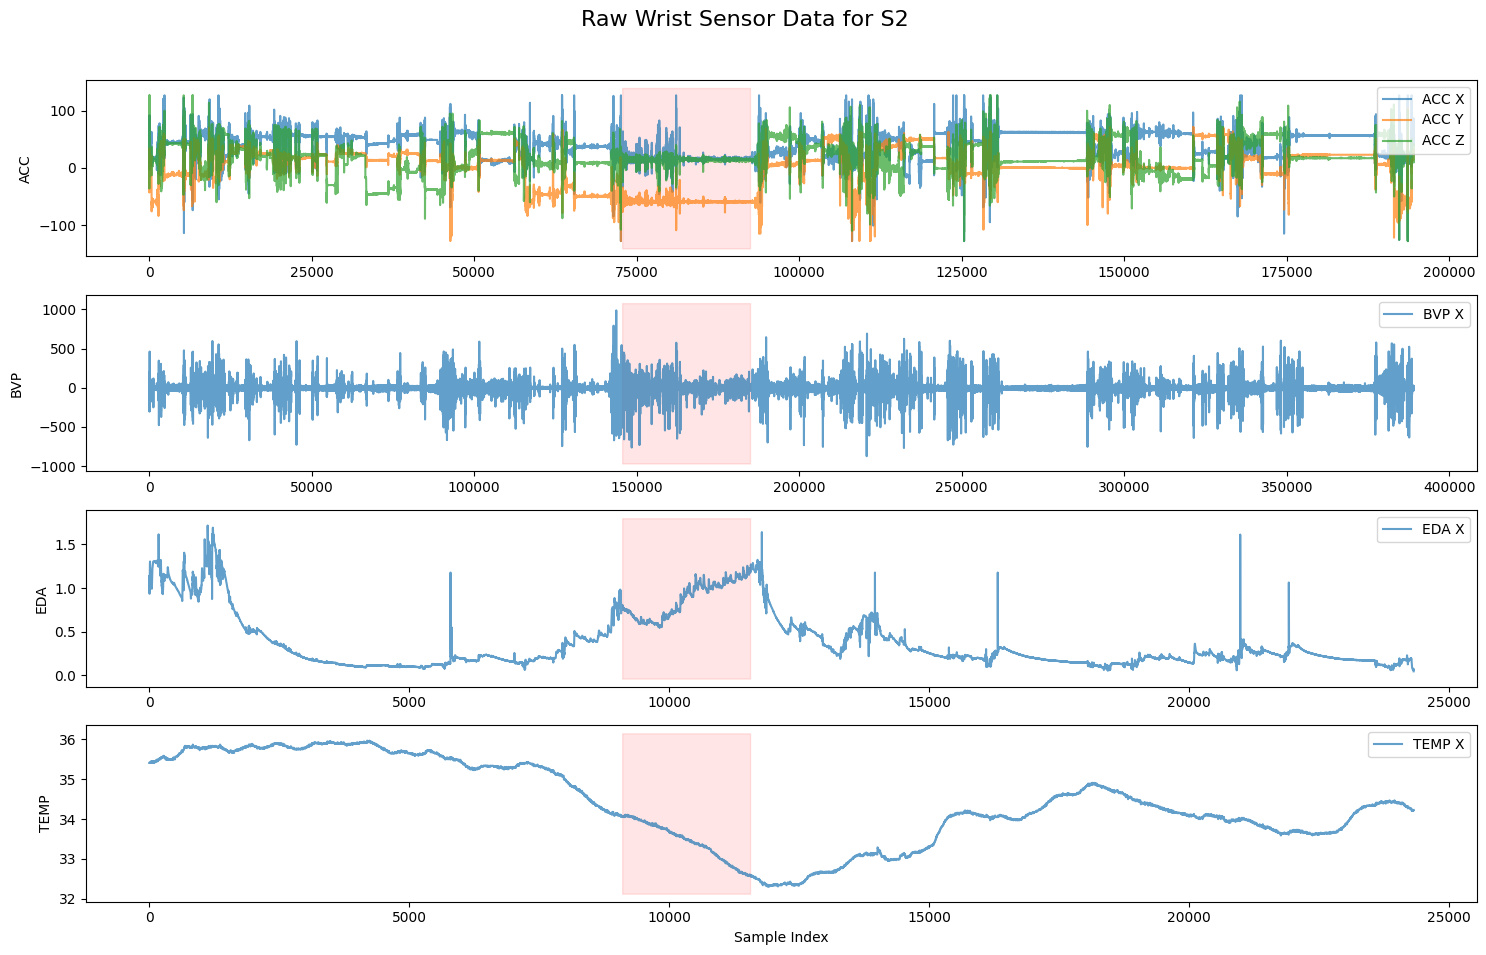

In [3]:
if data:
    # Extract signals and labels
    chest_signals = data['signal']['chest']
    wrist_signals = data['signal']['wrist']
    labels = data['label']

    # Define which channels to plot (based on common WESAD channels)
    # RespiBAN (chest) channels: ACC, ECG, EDA, EMG, RESP, TEMP
    # Empatica E4 (wrist) channels: ACC, BVP, EDA, TEMP

    # Select a few representative channels for visualization
    plot_chest_channels = ['ACC', 'ECG', 'EDA', 'TEMP']
    plot_wrist_channels = ['ACC', 'BVP', 'EDA', 'TEMP']

    # Plotting chest signals
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Raw Chest Sensor Data for {sample_subject}', fontsize=16)
    for i, channel in enumerate(plot_chest_channels):
        if channel in chest_signals and isinstance(chest_signals[channel], np.ndarray):
            plt.subplot(len(plot_chest_channels), 1, i + 1)
            if chest_signals[channel].ndim == 2:
                # For multi-dimensional data like ACC (x, y, z)
                plt.plot(chest_signals[channel][:, 0], label=f'{channel} X', alpha=0.7)
                if chest_signals[channel].shape[1] > 1:
                    plt.plot(chest_signals[channel][:, 1], label=f'{channel} Y', alpha=0.7)
                if chest_signals[channel].shape[1] > 2:
                    plt.plot(chest_signals[channel][:, 2], label=f'{channel} Z', alpha=0.7)
            else:
                plt.plot(chest_signals[channel], label=channel, alpha=0.7)
            plt.ylabel(channel)
            plt.legend(loc='upper right')
            # Add labels to the plot (downsample if necessary to match signal length)
            # This is a simplified approach; proper synchronization would be more complex
            resampled_labels = np.interp(
                np.arange(len(chest_signals[channel])) / len(chest_signals[channel]),
                np.arange(len(labels)) / len(labels),
                labels
            )
            # Highlight stress regions (label 2)
            stress_indices = np.where(resampled_labels == 2)[0]
            if len(stress_indices) > 0:
                plt.fill_between(stress_indices, plt.ylim()[0], plt.ylim()[1], color='red', alpha=0.1, label='Stress')
            
    plt.xlabel('Sample Index')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

    # Plotting wrist signals
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Raw Wrist Sensor Data for {sample_subject}', fontsize=16)
    for i, channel in enumerate(plot_wrist_channels):
        if channel in wrist_signals and isinstance(wrist_signals[channel], np.ndarray):
            plt.subplot(len(plot_wrist_channels), 1, i + 1)
            if wrist_signals[channel].ndim == 2:
                plt.plot(wrist_signals[channel][:, 0], label=f'{channel} X', alpha=0.7)
                if wrist_signals[channel].shape[1] > 1:
                    plt.plot(wrist_signals[channel][:, 1], label=f'{channel} Y', alpha=0.7)
                if wrist_signals[channel].shape[1] > 2:
                    plt.plot(wrist_signals[channel][:, 2], label=f'{channel} Z', alpha=0.7)
            else:
                plt.plot(wrist_signals[channel], label=channel, alpha=0.7)
            plt.ylabel(channel)
            plt.legend(loc='upper right')
            # Add labels to the plot (downsample if necessary to match signal length)
            # This is a simplified approach; proper synchronization would be more complex
            resampled_labels = np.interp(
                np.arange(len(wrist_signals[channel])) / len(wrist_signals[channel]),
                np.arange(len(labels)) / len(labels),
                labels
            )
            # Highlight stress regions (label 2)
            stress_indices = np.where(resampled_labels == 2)[0]
            if len(stress_indices) > 0:
                plt.fill_between(stress_indices, plt.ylim()[0], plt.ylim()[1], color='red', alpha=0.1, label='Stress')
    
    plt.xlabel('Sample Index')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

## Visualize Label Distribution Across All Subjects

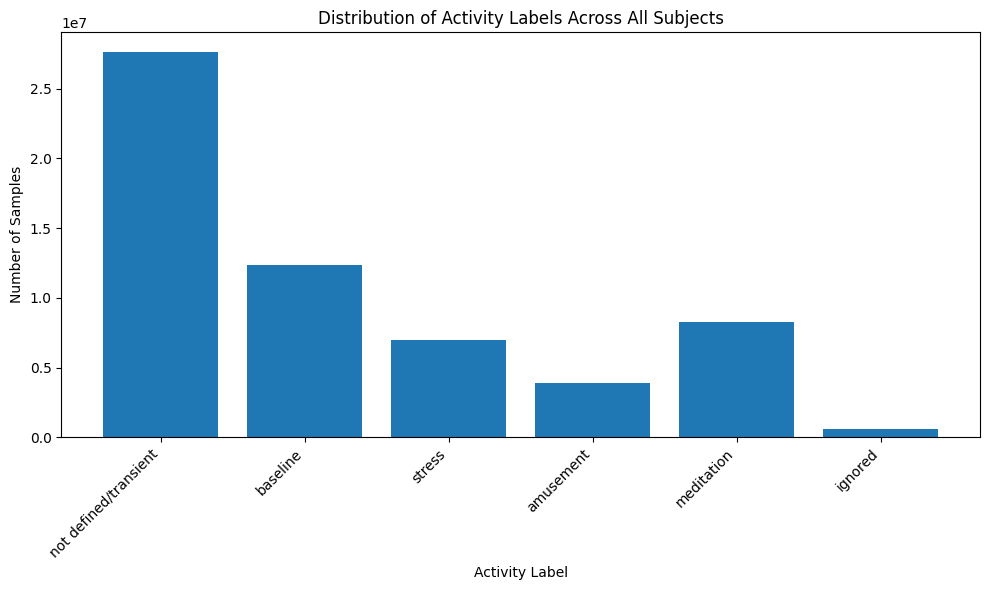

In [4]:
all_labels_combined = []

for subject in subjects:
    subject_path = os.path.join(WESAD_BASE_PATH, subject, f'{subject}.pkl')
    try:
        with open(subject_path, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        if 'label' in data:
            all_labels_combined.extend(data['label'])
    except FileNotFoundError:
        print(f"Warning: {subject_path} not found. Skipping.")
    except Exception as e:
        print(f"Warning: An error occurred while loading {subject_path}: {e}. Skipping.")

if all_labels_combined:
    all_labels_combined = np.array(all_labels_combined)
    unique_labels, label_counts = np.unique(all_labels_combined, return_counts=True)

    label_map = {
        0: 'not defined/transient',
        1: 'baseline',
        2: 'stress',
        3: 'amusement',
        4: 'meditation',
        5: 'ignored',
        6: 'ignored',
        7: 'ignored'
    }
    mapped_labels = [label_map.get(lbl, 'unknown') for lbl in unique_labels]

    plt.figure(figsize=(10, 6))
    plt.bar(mapped_labels, label_counts)
    plt.xlabel('Activity Label')
    plt.ylabel('Number of Samples')
    plt.title('Distribution of Activity Labels Across All Subjects')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No labels were loaded. Cannot visualize distribution.")